In [ ]:
pip install opencv-python matplotlib segment-anything


In [ ]:
import zipfile
import os

# Path to your zip file
zip_file_path = '/content/Images.zip'
# Destination folder where you want to unzip
destination_folder = '/content/images'

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_folder)

print(f"Unzipped files to: {destination_folder}")

Unzipped files to: /content/images


SAM loaded
Running on 1 images


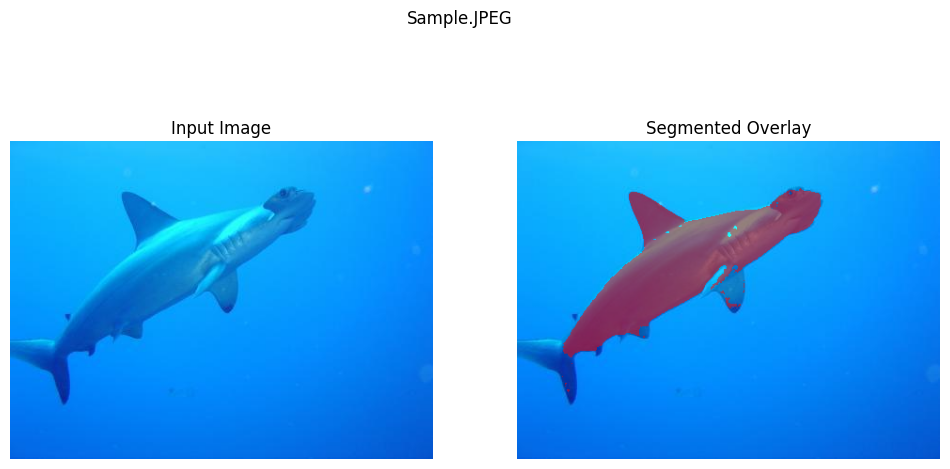

Segmentation done for 1 images


In [17]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

MODEL_TYPE = "vit_b"
CHECKPOINT_PATH = "/content/sam_vit_b_01ec64.pth"

IMAGE_FOLDER = "/content/images/Sample"

MIN_AREA = 50
MAX_AREA = 5000

assert os.path.exists(CHECKPOINT_PATH), "SAM checkpoint not found"
assert os.path.isdir(IMAGE_FOLDER), "Image folder not found"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)
print("SAM loaded")

def detect_blobs_otsu(gray):
    _, thresh = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    merged = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(
        merged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    points = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * area / (perimeter**2 + 1e-6)

        if MIN_AREA < area < MAX_AREA and 0.5 < circularity < 1.5:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                points.append((cx, cy))

    return points

def detect_blobs_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lower = np.array([0, 50, 50])
    upper = np.array([179, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(
        cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    points = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if MIN_AREA < area < MAX_AREA:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                points.append((cx, cy))

    return points

def get_fallback_points(image):
    h, w = image.shape[:2]
    return [
        (w // 2, h // 2),
        (w // 4, h // 4),
        (3 * w // 4, h // 4),
        (w // 4, 3 * h // 4),
        (3 * w // 4, 3 * h // 4),
    ]

segmented_images = {}

image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print(f"Running on {len(image_files)} images")

for img_name in image_files:
    img_path = os.path.join(IMAGE_FOLDER, img_name)

    image = cv2.imread(img_path)
    if image is None:
        print(f"Skipping {img_name}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    points_otsu = detect_blobs_otsu(gray)
    points_hsv = detect_blobs_hsv(image)
    candidate_points = points_otsu + points_hsv

    if len(candidate_points) == 0:
        candidate_points = get_fallback_points(image)

    input_points = np.array(candidate_points)
    input_labels = np.ones(len(input_points))

    masks, _, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False,
    )

    if masks is not None and len(masks) > 0:
        mask = masks[0].astype(np.uint8)
    else:
        mask = np.zeros(image.shape[:2], dtype=np.uint8)

    segmented_images[img_name] = mask

    overlay = image.copy()
    overlay[mask > 0] = [255, 0, 0]
    blended = cv2.addWeighted(image, 0.5, overlay, 0.5, 0)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(image)
    axs[0].set_title("Input Image")
    axs[0].axis("off")

    axs[1].imshow(blended)
    axs[1].set_title("Segmented Overlay")
    axs[1].axis("off")

    plt.suptitle(img_name)
    plt.show()

print(f"Segmentation done for {len(segmented_images)} images")


Model Abalation

In [14]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd
import random
import numpy as np

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_folder = "/content/images/200Images"
num_epochs = 20
batch_size = 1
learning_rate = 0.001

MODEL_FAMILIES = {
    "resnet": ["resnet18", "resnet50", "resnet101"],
    "densenet": ["densenet121", "densenet169", "densenet201"],
}

OUTPUT_CSVS = {
    "resnet": "/content/resnet_family_feature_norm.csv",
    "densenet": "/content/densenet_family_feature_norm.csv",
}

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

class SingleFolderDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.files = sorted(
            [f for f in os.listdir(folder_path)
             if f.lower().endswith((".png", ".jpg", ".jpeg"))],
            key=lambda x: int(os.path.splitext(x)[0])
        )
        self.folder_path = folder_path
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.files[idx])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

dataset = SingleFolderDataset(data_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

print("Images loaded:", len(dataset))

def get_model(name):
    if name.startswith("resnet"):
        model = getattr(models, name)(weights="DEFAULT")
        nf = model.fc.in_features
        model.fc = nn.Linear(nf, nf)
        final_layer = model.fc
    elif name.startswith("densenet"):
        model = getattr(models, name)(weights="DEFAULT")
        nf = model.classifier.in_features
        model.classifier = nn.Linear(nf, nf)
        final_layer = model.classifier
    else:
        raise ValueError(name)

    for p in model.parameters():
        p.requires_grad = False
    for p in final_layer.parameters():
        p.requires_grad = True

    return model.to(device)

for family_name, model_list in MODEL_FAMILIES.items():
    print("\nRunning family:", family_name)
    feature_dict = {img: {} for img in dataset.files}

    for model_name in model_list:
        print("Model:", model_name)
        model = get_model(model_name)
        optimizer = torch.optim.Adam(
            [p for p in model.parameters() if p.requires_grad],
            lr=learning_rate
        )
        criterion = nn.MSELoss()

        model.train()
        for epoch in range(num_epochs):
            for inputs, _ in dataloader:
                inputs = inputs.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, outputs.detach())
                loss.backward()
                optimizer.step()
            print(f"  Epoch {epoch + 1}/{num_epochs} completed")

        model.eval()
        with torch.no_grad():
            for i, (inputs, _) in enumerate(dataloader):
                inputs = inputs.to(device)
                outputs = model(inputs)
                val = outputs.norm(dim=1).mean().item()
                feature_dict[dataset.files[i]][
                    f"{model_name}_feature_norm"
                ] = val

    df = pd.DataFrame.from_dict(feature_dict, orient="index")
    df.index.name = "image_name"
    df.to_csv(OUTPUT_CSVS[family_name])
    print("Saved CSV:", OUTPUT_CSVS[family_name])

print("\nModel-family ablation finished.")


Device: cuda
Images loaded: 200

Running family: resnet
Model: resnet18
  Epoch 1/20 completed
  Epoch 2/20 completed
  Epoch 3/20 completed
  Epoch 4/20 completed
  Epoch 5/20 completed
  Epoch 6/20 completed
  Epoch 7/20 completed
  Epoch 8/20 completed
  Epoch 9/20 completed
  Epoch 10/20 completed
  Epoch 11/20 completed
  Epoch 12/20 completed
  Epoch 13/20 completed
  Epoch 14/20 completed
  Epoch 15/20 completed
  Epoch 16/20 completed
  Epoch 17/20 completed
  Epoch 18/20 completed
  Epoch 19/20 completed
  Epoch 20/20 completed
Model: resnet50
  Epoch 1/20 completed
  Epoch 2/20 completed
  Epoch 3/20 completed
  Epoch 4/20 completed
  Epoch 5/20 completed
  Epoch 6/20 completed
  Epoch 7/20 completed
  Epoch 8/20 completed
  Epoch 9/20 completed
  Epoch 10/20 completed
  Epoch 11/20 completed
  Epoch 12/20 completed
  Epoch 13/20 completed
  Epoch 14/20 completed
  Epoch 15/20 completed
  Epoch 16/20 completed
  Epoch 17/20 completed
  Epoch 18/20 completed
  Epoch 19/20 comp

Dataset Abalation


In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import random
import numpy as np

SEED = 0
EPOCHS = 20
BATCH_SIZE = 1
LR = 0.001

DATASETS = {
    100: "/content/images/100Images",
    200: "/content/images/200Images",
    300: "/content/images/300Images",
}

OUTPUT_RESNET = "/content/dataset_size_vs_feature_norm_resnet18.csv"
OUTPUT_DENSENET = "/content/dataset_size_vs_feature_norm_densenet121.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def reset_seeds():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

class SingleFolderDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.files = sorted(
            [f for f in os.listdir(folder_path)
             if f.lower().endswith((".png", ".jpg", ".jpeg"))],
            key=lambda x: int(os.path.splitext(x)[0])
        )
        self.folder_path = folder_path
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.files[idx])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.files[idx]

def get_resnet18():
    reset_seeds()
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    nf = model.fc.in_features
    model.fc = nn.Linear(nf, nf)

    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True

    return model.to(device)

def get_densenet121():
    reset_seeds()
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    nf = model.classifier.in_features
    model.classifier = nn.Linear(nf, nf)

    for p in model.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True

    return model.to(device)

all_image_names = set()
for p in DATASETS.values():
    all_image_names |= set(os.listdir(p))

all_image_names = sorted(
    [f for f in all_image_names if f.lower().endswith((".jpg", ".jpeg", ".png"))],
    key=lambda x: int(os.path.splitext(x)[0])
)

resnet_results = {
    img: {f"feature_norm_{k}": None for k in DATASETS.keys()}
    for img in all_image_names
}

densenet_results = {
    img: {f"feature_norm_{k}": None for k in DATASETS.keys()}
    for img in all_image_names
}

criterion = nn.MSELoss()

for size, folder in DATASETS.items():
    print(f"\nDataset size: {size}")
    dataset = SingleFolderDataset(folder, transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("Training ResNet-18")
    resnet = get_resnet18()
    opt_r = torch.optim.Adam(
        [p for p in resnet.parameters() if p.requires_grad], lr=LR
    )

    resnet.train()
    for epoch in range(EPOCHS):
        for x, _ in loader:
            x = x.to(device)
            opt_r.zero_grad()
            y = resnet(x)
            loss = criterion(y, y.detach())
            loss.backward()
            opt_r.step()
        print(f"  ResNet epoch {epoch + 1}/{EPOCHS} completed")

    resnet.eval()
    with torch.no_grad():
        for x, name in loader:
            x = x.to(device)
            val = resnet(x).norm(dim=1).mean().item()
            resnet_results[name[0]][f"feature_norm_{size}"] = val

    print("Training DenseNet-121")
    densenet = get_densenet121()
    opt_d = torch.optim.Adam(
        [p for p in densenet.parameters() if p.requires_grad], lr=LR
    )

    densenet.train()
    for epoch in range(EPOCHS):
        for x, _ in loader:
            x = x.to(device)
            opt_d.zero_grad()
            y = densenet(x)
            loss = criterion(y, y.detach())
            loss.backward()
            opt_d.step()
        print(f"  DenseNet epoch {epoch + 1}/{EPOCHS} completed")

    densenet.eval()
    with torch.no_grad():
        for x, name in loader:
            x = x.to(device)
            val = densenet(x).norm(dim=1).mean().item()
            densenet_results[name[0]][f"feature_norm_{size}"] = val

df_r = pd.DataFrame.from_dict(resnet_results, orient="index").fillna("NULL")
df_r.index.name = "image_name"
df_r.to_csv(OUTPUT_RESNET)
print("Saved:", OUTPUT_RESNET)

df_d = pd.DataFrame.from_dict(densenet_results, orient="index").fillna("NULL")
df_d.index.name = "image_name"
df_d.to_csv(OUTPUT_DENSENET)
print("Saved:", OUTPUT_DENSENET)

print("\nDataset-size ablation finished.")


Using device: cuda

Dataset size: 100
Training ResNet-18
  ResNet epoch 1/20 completed
  ResNet epoch 2/20 completed
  ResNet epoch 3/20 completed
  ResNet epoch 4/20 completed
  ResNet epoch 5/20 completed
  ResNet epoch 6/20 completed
  ResNet epoch 7/20 completed
  ResNet epoch 8/20 completed
  ResNet epoch 9/20 completed
  ResNet epoch 10/20 completed
  ResNet epoch 11/20 completed
  ResNet epoch 12/20 completed
  ResNet epoch 13/20 completed
  ResNet epoch 14/20 completed
  ResNet epoch 15/20 completed
  ResNet epoch 16/20 completed
  ResNet epoch 17/20 completed
  ResNet epoch 18/20 completed
  ResNet epoch 19/20 completed
  ResNet epoch 20/20 completed
Training DenseNet-121
  DenseNet epoch 1/20 completed
  DenseNet epoch 2/20 completed
  DenseNet epoch 3/20 completed
  DenseNet epoch 4/20 completed
  DenseNet epoch 5/20 completed
  DenseNet epoch 6/20 completed
  DenseNet epoch 7/20 completed
  DenseNet epoch 8/20 completed
  DenseNet epoch 9/20 completed
  DenseNet epoch 10/20